In [1]:
from langgraph.graph import START, StateGraph
from typing import TypedDict

# Define subgraph
class SubgraphState(TypedDict):
    foo: str  # note that this key is shared with the parent graph state
    bar: str

def subgraph_node_1(state: SubgraphState):
    return {"bar": "bar"}

def subgraph_node_2(state: SubgraphState):
    return {"foo": state["foo"] + state["bar"]}

subgraph_builder = StateGraph(SubgraphState)
subgraph_builder.add_node(subgraph_node_1)
subgraph_builder.add_node(subgraph_node_2)
subgraph_builder.add_edge(START, "subgraph_node_1")
subgraph_builder.add_edge("subgraph_node_1", "subgraph_node_2")
subgraph = subgraph_builder.compile()


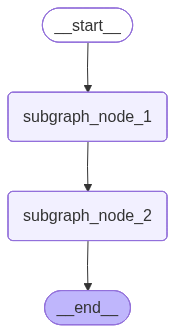

In [2]:
subgraph

In [3]:
# Define parent graph
class ParentState(TypedDict):
    foo: str

def node_1(state: ParentState):
    return {"foo": "hi! " + state["foo"]}

builder = StateGraph(ParentState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", subgraph)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
graph = builder.compile()



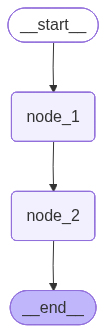

In [4]:
graph

In [5]:
for chunk in graph.stream(
    {"foo": "foo"},
    stream_mode="updates",
    # Set subgraphs=True to stream outputs from subgraphs
    subgraphs=True,
    version="v2",
):
    if chunk["type"] == "updates":
        if chunk["ns"]:
            print(f"Subgraph {chunk['ns']}: {chunk['data']}")
        else:
            print(f"Root: {chunk['data']}")

Root: {'node_1': {'foo': 'hi! foo'}}
Subgraph ('node_2:98ed5e96-cd20-1866-64c6-245313830fb4',): {'subgraph_node_1': {'bar': 'bar'}}
Subgraph ('node_2:98ed5e96-cd20-1866-64c6-245313830fb4',): {'subgraph_node_2': {'foo': 'hi! foobar'}}
Root: {'node_2': {'foo': 'hi! foobar'}}
